# load simulations

In [18]:
%load_ext autoreload
%autoreload 2
from pydeconv.utils import *
from pydeconv.pydeconv_sims import *
import numpy as np
import mne

# %matplotlib qt 
n_seconds = 3000        # Duration of the signal in seconds
sfreq = 500            # Sampling frequency in Hz
sig = EEGSimulator(n_seconds, sfreq)
# transition probabilities
W_matrix = [[0, 0.45, 0.45, 0.1],
            [0.9, 0, 0 , .1],
            [0.9, 0, 0,.1],
            [.33,.33,.33,0]]
kernels = {
            0: {'onsets': [0, 0.19, 0.25], 'amplitudes': [0.1, -0.05, 0.04], 'widths': [0.05, 0.05, 0.07], 'weight':0.3},
            1: {'onsets': [0, 0.19, 0.25], 'amplitudes': [0.1, -0.05, 0.04], 'widths': [0.05, 0.05, 0.07], 'weight':0.3},
            2: {'onsets': [0, 0.19, 0.25], 'amplitudes': [0.1, -0.07, 0.04], 'widths': [0.05, 0.05, 0.07], 'weight':0.3},
            3: {'onsets': [0, 0.19, 0.25], 'amplitudes': [0.1, -0.07, 0.04], 'widths': [0.05, 0.05, 0.07], 'weight':0.3},
            'modulation': {'ker_idx2mod': 1, 'mod': 'linear','dist': 'uniform', 'lims': [100, 600]}
        }

sig.create_isi_pdf(0, sample_size=100, lims=[.01, .15], dist_type='skewed', mode=.05, skew=0, scale=.01)
sig.create_isi_pdf(1, sample_size=100, lims=[.1, .6], dist_type='skewed', mode=.3, skew=2, scale=.05)
sig.create_isi_pdf(2, sample_size=100, lims=[.1, .6], dist_type='skewed', mode=.3, skew=2, scale=.05)
sig.create_isi_pdf(3, sample_size=100, lims=[.1, .6], dist_type='uniform')


# sig.combine_isi_pdf
# sig.plot_isi_pdf(0)
# sig.plot_isi_pdf(1)

################
sig.simulate(noise="brown",erp_ker=kernels,w_matrix=W_matrix)

# create evts

# Copy and modify the event data
evts = sig.evts.copy()

# Set the event type to filter (event_id 1 for example)
event_id1 = 1
event_id2 = 2

# Filter events where `type == event_id`
filtered_evts = evts.loc[(evts['type'] == event_id1) | (evts['type'] == event_id2)]

# Get the number of filtered events
n_events = len(filtered_evts)

# Ensure that latencies are integer values
latencies = filtered_evts['latency'].values.astype(int)

# Create the events array for MNE
# Column 1: Latencies
# Column 2: Zeros (assuming no previous event values, hence zeros)
# Column 3: Event types (all set to 1 since filtered for `event_id`)
mne_events = np.column_stack((latencies,
                              np.zeros(n_events, dtype=int),
                              np.ones(n_events, dtype=int)))

# Print or use `mne_events` as needed
print(mne_events[:5])
#create RAW
# Creating simulated RAW

# Parameters

n_samples = n_seconds * sfreq  # Total number of samples
n_channels = 1         # Number of channels (virtual channel)

# Create random data for the virtual channel (shape: [n_samples])
data = sig.data

# Reshape the data to be 2D (n_channels, n_samples)
data = data.reshape((n_channels, n_samples))

# Create MNE info object
ch_names = ['VirtualEEG']  # Name of the virtual channel
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')

# Create the Raw object from the reshaped data array
raw = mne.io.RawArray(data, info)

evts['type'].value_counts()

# Update 'effect' column
evts['effect'] = evts['type'].apply(lambda x: True if x == 2 else False if x == 1 else np.nan)

# Replace all 2s with 1s in 'type' column
evts['type'] = evts['type'].replace(2, 1)
evts['type'].value_counts()
columns = {'latencies':latencies,	'type':'type','categorical':'categorical','continuous':'continuous'}
# evts.rename(columns=columns, inplace=True)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[[  5   0   1]
 [175   0   1]
 [255   0   1]
 [381   0   1]
 [438   0   1]]
Creating RawArray with float64 data, n_channels=1, n_times=1500000
    Range : 0 ... 1499999 =      0.000 ...  2999.998 secs
Ready.


## SK with simulation

Analyzing data with model: testingSims
Time range: -0.2 to 0.6
Solver: ridge

Model Name: testingSims
First Intercept Event Type: 1
Second Intercept Event Type: 0
Sampling Frequency: 500.0
Time Window: -0.2 to 0.6
Channels to Analyze: 1

Model Description:
Intercept: True
Additive Features: ['effect']
Interactions: None


Original Design Matrix Shape:
X_design shape: (1500000, 1203)
y_data shape: (1500000, 1)


Training completed in 0:00:03.572953
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.


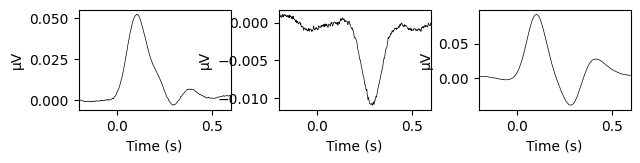

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import torch
import numpy as np
from scipy import sparse

def normalize_data(X, y):
    """Center the data like sklearn"""
    # Convert sparse matrix to dense numpy array if necessary
    if sparse.issparse(X):
        X = X.toarray()
    if sparse.issparse(y):
        y = y.toarray()
    
    # Ensure X and y are numpy arrays
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)
    
    # Compute mean
    X_mean = X.mean(axis=0)
    y_mean = y.mean(axis=0)
    
    # Compute standard deviation
    X_std = X.std(axis=0, ddof=1)
    
    # Prevent division by zero
    X_std = np.where(X_std == 0, 1.0, X_std)
    
    # Center and scale X, only center y
    X_normalized = (X - X_mean) / (X_std + 1e-8)
    y_normalized = y - y_mean
    
    # Convert to torch tensors if needed
    X_normalized = torch.tensor(X_normalized, dtype=torch.float32)
    y_normalized = torch.tensor(y_normalized, dtype=torch.float32)
    
    return X_normalized, y_normalized

def ridge_loss_custom(rERP_model,X, y):
    """
    Implement loss exactly like sklearn's Ridge:
    Loss = (1/(2*n_samples)) * ||y - Xw||^2 + (alpha/(2*n_samples)) * ||w||^2
    """
    n_samples = y.shape[0]
    
    # MSE term
    mse_loss = torch.sum((rERP_model.predict(X) - y) ** 2) / (2 * n_samples)
    
    # L2 regularization term (exclude bias from regularization like sklearn)
    ridge_penalty = (rERP_model.estimator.alpha / (2 * n_samples)) * torch.sum(rERP_model.coef_ ** 2)
    
    return mse_loss + ridge_penalty, mse_loss.item(), ridge_penalty.item()

# Note: The rest of the code seems to depend on context and other imported modules 
# that are not shown here (pydeconv, config4test, etc.). I'm making some assumptions.

# Assuming these are defined elsewhere in your code
from pydeconv import *
import config4test
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error

# Main script
settings = analyze_data(config4test)
features = evts
# raw = raw (commented out in original code)

# Initialize the model
rERP_model = PyDeconv(settings=settings, features=features, eeg=raw, normalize=True)
X_design = rERP_model.create_matrix()
y_data = rERP_model.get_nonzero_data()

# Normalize data
X_design, y_data = normalize_data(X_design, y_data)

# Model Selection
solver = rERP_model.estimator
num_folds = 5
alphas = np.linspace(5, 500, 20)
param_grid = {'alpha': alphas.tolist()}

# Uncomment if you want to use grid search
# kf = KFold(n_splits=num_folds)
# grid_search = GridSearchCV(estimator=solver,
#                            param_grid=param_grid,
#                            scoring='neg_mean_squared_error',
#                            cv=kf, 
#                            verbose=5)
# grid_search.fit(X_design, y_data)
# best_model = grid_search.best_estimator_

# Set alpha manually or use best alpha from grid search
rERP_model.estimator.set_params(alpha=5)
rERP_model.fit(X_design, y_data)

# Plotting
rERP_model.plot_coefs(top_topos=False)
plt.show()

In [24]:
ridge_loss_custom(rERP_model,X_design, y_data)

TypeError: unsupported operand type(s) for -: 'numpy.ndarray' and 'Tensor'

In [6]:
# Predicting the maximum value
max_prediction = rERP_model.predict(X_design).max()
print("Maximum prediction:", max_prediction)

# Calculating the model score
score = rERP_model.sk_score(X_design, y_data)
print("Model score:", score)

Maximum prediction: 2.1012198711189676
Model score: 0.8560873059136378


In [7]:
rERP_model.predict(X_design).max()
rERP_model.sk_score(X_design,y_data)



0.8560873059136378

In [13]:
# r2 score custom
y_pred = rERP_model.predict(X_design)  # PyTorch tensor
# Compute the mean of true values
y_mean = y_data.mean(dim=0)
# Compute SS_res and SS_tot
ss_res = torch.sum((y_data - y_pred) ** 2, dim=0)  # Residual sum of squares
ss_tot = torch.sum((y_data - y_mean) ** 2, dim=0)  # Total sum of squares
# Calculate R²
r2 = 1 - (ss_res / (ss_tot + 1e-8))  # Add small value to avoid division by zero
# Return R² as a scalar mean
score = r2.mean().item()
print("r2 calculated by hand sk is", score)
print("r2 TORCh", torch_ridge.custom_r2_score(X_design,y_data)
 )

r2 calculated by hand sk is 0.8560873061132706
r2 TORCh 0.86518264


In [ ]:
print("prediction max sk", rERP_model.predict(X_design).max())
print("sk sd", rERP_model.predict(X_design).std())
print("sk mean", rERP_model.predict(X_design).mean())
print("prediction max torch", torch_ridge.predict(X_design).max())
print("sd torch", torch_ridge.predict(X_design).std())
print("torch mean", torch_ridge.predict(X_design).mean())


prediction max sk 2.1012198711189676
sk sd 0.6100854112250227
sk mean 6.173262969578315e-08
prediction max torch 1.9930131
sd torch 0.5700875
torch mean 3.1168037e-07


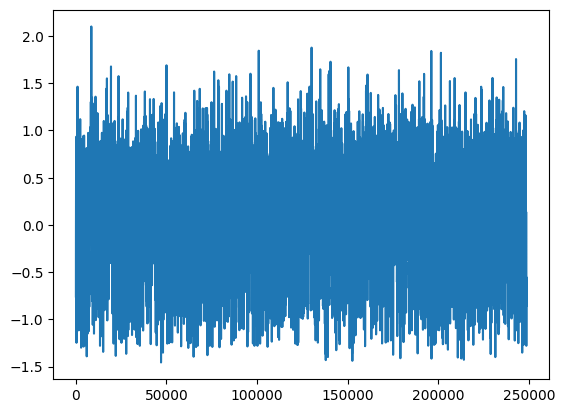

In [16]:
plt.plot( rERP_model.predict(X_design))


In [17]:
torch_ridge.custom_r2_score(X_design,y_data)


0.86518264

In [39]:
# r2 score custom
y_pred = torch_ridge.predict(X_design)  # PyTorch tensor
# Compute the mean of true values
y_mean = y_data.mean(dim=0)
# Compute SS_res and SS_tot
ss_res = torch.sum((y_data - y_pred) ** 2, dim=0)  # Residual sum of squares
ss_tot = torch.sum((y_data - y_mean) ** 2, dim=0)  # Total sum of squares
# Calculate R²
r2 = 1 - (ss_res / (ss_tot + 1e-8))  # Add small value to avoid division by zero
# Return R² as a scalar mean
score = r2.mean().item()
print("r2 calculated by hand for torch is", score)

TypeError: unsupported operand type(s) for -: 'Tensor' and 'NoneType'

## Torch

/tmp/ipykernel_1265539/2740919027.py:251: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_torch = torch.tensor(X_design).float().to(device)  # Convert to dense PyTorch tensor
/tmp/ipykernel_1265539/2740919027.py:252: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_torch = torch.tensor(y_data).float().to(device)


Epoch 0/8, Total Loss: 0.144562, MSE: 0.144547, Ridge: 0.000015, Elapsed: 0:00:00, ETA: 0:00:00

Training completed in 0:00:00.146744


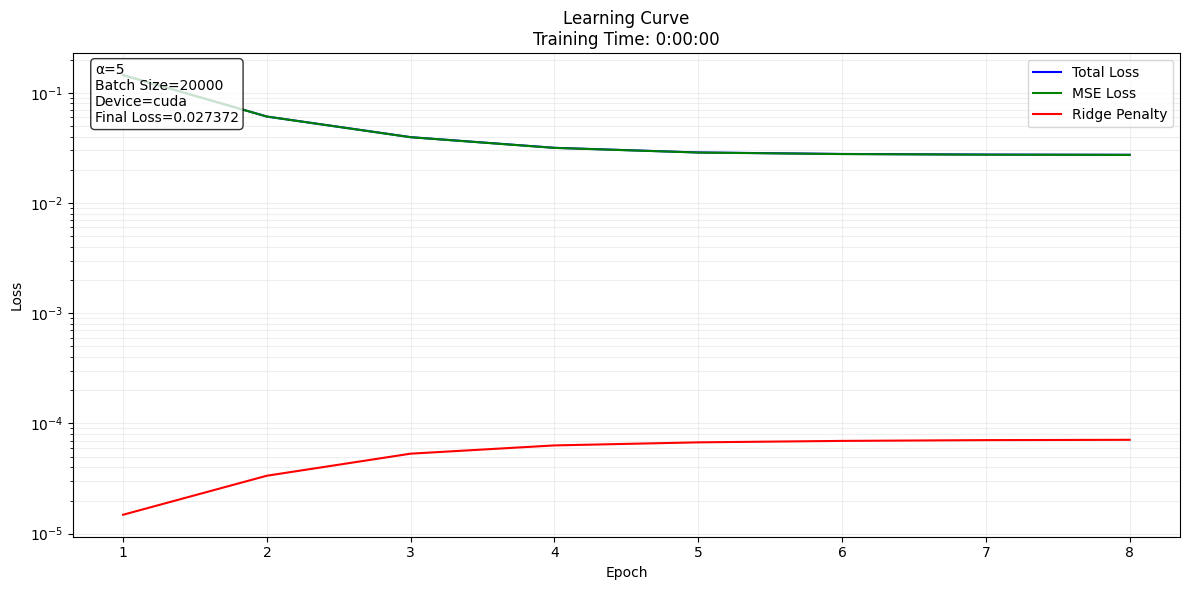

Predictions shape: (251735, 1)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.


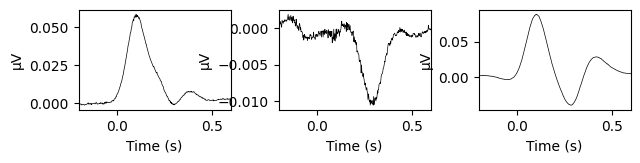

In [27]:
import torch
import torch.optim as optim
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import timedelta

class RidgeDeconvolution:
    def __init__(self, input_dim, output_dim, alpha=1.0, fit_intercept=True, batch_size=100, device='cpu'):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size
        self.device = device
        self.loss_history = {'total': [], 'mse': [], 'ridge': []}
        self.training_time = None
        
        # Initialize weights closer to zero
        self.linear = nn.Linear(input_dim, output_dim, bias=fit_intercept).to(device)
        nn.init.normal_(self.linear.weight, mean=0.0, std=0.01)
        if fit_intercept:
            nn.init.zeros_(self.linear.bias)
        
        self.X_mean = None
        self.X_std = None
        self.y_mean = None
        self.y_std = None

    def normalize_data(self, X, y):
        """Center the data like sklearn"""
        if self.X_mean is None:
            self.X_mean = X.mean(dim=0, keepdim=True)
            self.y_mean = y.mean(dim=0, keepdim=True)
            
            # Only scale X like sklearn's Ridge
            self.X_std = torch.sqrt(torch.sum((X - self.X_mean)**2, dim=0, keepdim=True) / X.shape[0])
            self.y_std = None  # Don't scale y
        
        # Center and scale X, only center y
        X_normalized = (X - self.X_mean) / (self.X_std + 1e-8)
        y_normalized = y - self.y_mean if self.fit_intercept else y
        
        return X_normalized, y_normalized

    def loss(self, predictions, y):
        """
        Implement loss exactly like sklearn's Ridge:
        Loss = (1/(2*n_samples)) * ||y - Xw||^2 + (alpha/(2*n_samples)) * ||w||^2
        """
        n_samples = y.shape[0]
        
        # MSE term
        mse_loss = torch.sum((predictions - y) ** 2) / (2 * n_samples)
        
        # L2 regularization term (exclude bias from regularization like sklearn)
        ridge_penalty = (self.alpha / (2 * n_samples)) * torch.sum(self.linear.weight ** 2)
        
        return mse_loss + ridge_penalty, mse_loss.item(), ridge_penalty.item()

    def fit(self, X, y, epochs=1000, lr=0.01):
        start_time = time.time()

        # Ensure input is a PyTorch tensor and stays on CPU
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
        if not isinstance(y, torch.Tensor):
            y = torch.tensor(y, dtype=torch.float32)

        # Normalize data (still on CPU)
        X, y = self.normalize_data(X, y)

        n_samples = X.shape[0]

        # Use Adam optimizer
        optimizer = optim.Adam(self.linear.parameters(), lr=lr, eps=1e-8)

        for epoch in range(epochs):
            total_loss = 0
            total_mse = 0
            total_ridge = 0
            num_batches = 0

            for i in range(0, n_samples, self.batch_size):
                batch_end = min(i + self.batch_size, n_samples)

                # Move batch to GPU, keeping rest on CPU
                X_batch = X[i:batch_end].to(self.device, non_blocking=True)
                y_batch = y[i:batch_end].to(self.device, non_blocking=True)

                optimizer.zero_grad()
                predictions = self.linear(X_batch)

                loss, mse, ridge = self.loss(predictions, y_batch)
                loss.backward()

                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(self.linear.parameters(), max_norm=1.0)
                optimizer.step()

                total_loss += loss.item() * (batch_end - i)
                total_mse += mse * (batch_end - i)
                total_ridge += ridge * (batch_end - i)
                num_batches += 1

                # Explicitly delete batch and clear cache
                del X_batch, y_batch, predictions
                torch.cuda.empty_cache()

            avg_loss = total_loss / n_samples
            avg_mse = total_mse / n_samples
            avg_ridge = total_ridge / n_samples

            self.loss_history['total'].append(avg_loss)
            self.loss_history['mse'].append(avg_mse)
            self.loss_history['ridge'].append(avg_ridge)

            if epoch > 10 and abs(self.loss_history['total'][-1] - self.loss_history['total'][-2]) < 1e-7:
                print(f"Converged at epoch {epoch}")
                break

            if epoch % 10 == 0:
                elapsed = time.time() - start_time
                eta = (elapsed / (epoch + 1)) * (epochs - epoch - 1)
                print(f"Epoch {epoch}/{epochs}, Total Loss: {avg_loss:.6f}, "
                    f"MSE: {avg_mse:.6f}, Ridge: {avg_ridge:.6f}, "
                    f"Elapsed: {timedelta(seconds=int(elapsed))}, "
                    f"ETA: {timedelta(seconds=int(eta))}")

        self.training_time = time.time() - start_time
        print(f"\nTraining completed in {timedelta(seconds=self.training_time)}")


    def predict(self, X):
        """Predict like sklearn's Ridge"""
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
        
        X = X.to(self.device)
        
        self.linear.eval()
        with torch.no_grad():
            X_normalized = (X - self.X_mean)/ (self.X_std + 1e-8)
            predictions = self.linear(X_normalized)
            if self.fit_intercept:
                predictions = predictions + self.y_mean
            
        return predictions.cpu().numpy()

    def get_coefficients(self):
        """Get coefficients in the original scale like sklearn"""
        with torch.no_grad():
            # Get weights
            weights = self.linear.weight.cpu()
            
            # Rescale weights
            scaled_weights = weights/ (self.X_std + 1e-8).cpu()
            
            # Get intercept if fitted
            if self.fit_intercept:
                intercept = self.y_mean.cpu() - torch.mm(self.X_mean.cpu(), scaled_weights.t())
            else:
                intercept = torch.zeros(self.linear.out_features)
            
            return scaled_weights.numpy(), intercept.numpy()

    def plot_learning_curve(self, log_scale=True):
        """
        Plot the learning curve showing total loss, MSE, and ridge penalty components
        """
        plt.figure(figsize=(12, 6))
        epochs = range(1, len(self.loss_history['total']) + 1)
        
        plt.plot(epochs, self.loss_history['total'], 'b-', label='Total Loss')
        plt.plot(epochs, self.loss_history['mse'], 'g-', label='MSE Loss')
        plt.plot(epochs, self.loss_history['ridge'], 'r-', label='Ridge Penalty')
        
        plt.title(f'Learning Curve\nTraining Time: {timedelta(seconds=int(self.training_time))}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        
        if log_scale:
            plt.yscale('log')
        
        plt.grid(True, which="both", ls="-", alpha=0.2)
        plt.legend()
        
        # Add training details as text
        details = (f'α={self.alpha}\n'
                  f'Batch Size={self.batch_size}\n'
                  f'Device={self.device}\n'
                  f'Final Loss={self.loss_history["total"][-1]:.6f}')
        plt.text(0.02, 0.98, details, 
                transform=plt.gca().transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
    def custom_r2_score(self, X, y):
            """
            Compute the R^2 (coefficient of determination) for the model.
            
            Parameters:
            -----------
            X : array-like of shape (n_samples, n_features)
                Test samples.
            y : array-like of shape (n_samples,) or (n_samples, n_targets)
                True values for X.
                
            Returns:
            --------
            score : float or ndarray
                R^2 of self.predict(X) with respect to y.
                
            Notes:
            ------
            R^2 = 1 - (SS_res / SS_tot)
            """
            # Ensure inputs are tensors on the CPU
            if not isinstance(X, torch.Tensor):
                X = torch.tensor(X, dtype=torch.float32, device="cpu")
            if not isinstance(y, torch.Tensor):
                y = torch.tensor(y, dtype=torch.float32, device="cpu")
            
            # Obtain predictions (ensured to return on CPU in self.predict)
            y_pred = self.predict(X)  # Returns a NumPy array
            y_pred = torch.tensor(y_pred, dtype=torch.float32, device="cpu")
            
            # Compute the mean of true values
            y_mean = torch.mean(y, dim=0)
            
            # Compute SS_res and SS_tot
            ss_res = torch.sum((y - y_pred) ** 2, dim=0)  # Residual sum of squares
            ss_tot = torch.sum((y - y_mean) ** 2, dim=0)  # Total sum of squares
            
            # Calculate R²
            r2 = 1 - (ss_res / (ss_tot + 1e-8))  # Add small value to avoid division by zero
            
            # Return R² as a NumPy array
            return r2.numpy().mean()


        
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Generate or load your design matrix for deconvolution (X_design)
    # and your response vector/matrix (y_data), ensuring that X_design 
    # properly reflects event separation with a Toeplitz structure if needed.
    X_torch = torch.tensor(X_design).float().to(device)  # Convert to dense PyTorch tensor
    y_torch = torch.tensor(y_data).float().to(device)

    # Instantiate and train the deconvolution Ridge model
    torch_ridge = RidgeDeconvolution(input_dim=X_design.shape[1], output_dim=1, alpha=5, fit_intercept=False, batch_size=20000, device=device)
    torch_ridge.fit(X_torch, y_torch, epochs=8,lr=0.002)
    
    # Plot learning curve
    torch_ridge.plot_learning_curve()

    # Predictions
    torch_predictions = torch_ridge.predict(X_torch)
    print("Predictions shape:", torch_predictions.shape)
    # coeffs =  torch_ridge.linear.weight.detach().cpu().numpy()
    coeffs = torch_ridge.get_coefficients()[0]
    rERP_model.coef_ =  coeffs
    # # Predictions should now have shape (13000, 3)
    # torch_predictions = torch_ridge.predict(X_torch)
    rERP_model.plot_coefs(top_topos=False)


In [49]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Convert inputs to torch tensors if needed
if not isinstance(X_design, torch.Tensor):
    X_design = torch.tensor(X_design.todense(), dtype=torch.float32)
if not isinstance(y_data, torch.Tensor):
    y_data = torch.tensor(y_data, dtype=torch.float32)
# n_samples = X_design.shape[0]
# i = 2
# batch_end = min(i + 200000, n_samples)

# # Move batch to device
# X_batch = X_design[i:batch_end].to(device)
# y_batch = y_data[i:batch_end].to(device)




Epoch 0/20, Total Loss: 0.140777, MSE: 0.140763, Ridge: 0.000014, Elapsed: 0:00:00, ETA: 0:00:01
Epoch 10/20, Total Loss: 0.027240, MSE: 0.027168, Ridge: 0.000071, Elapsed: 0:00:00, ETA: 0:00:00

Training completed in 0:00:00.297262


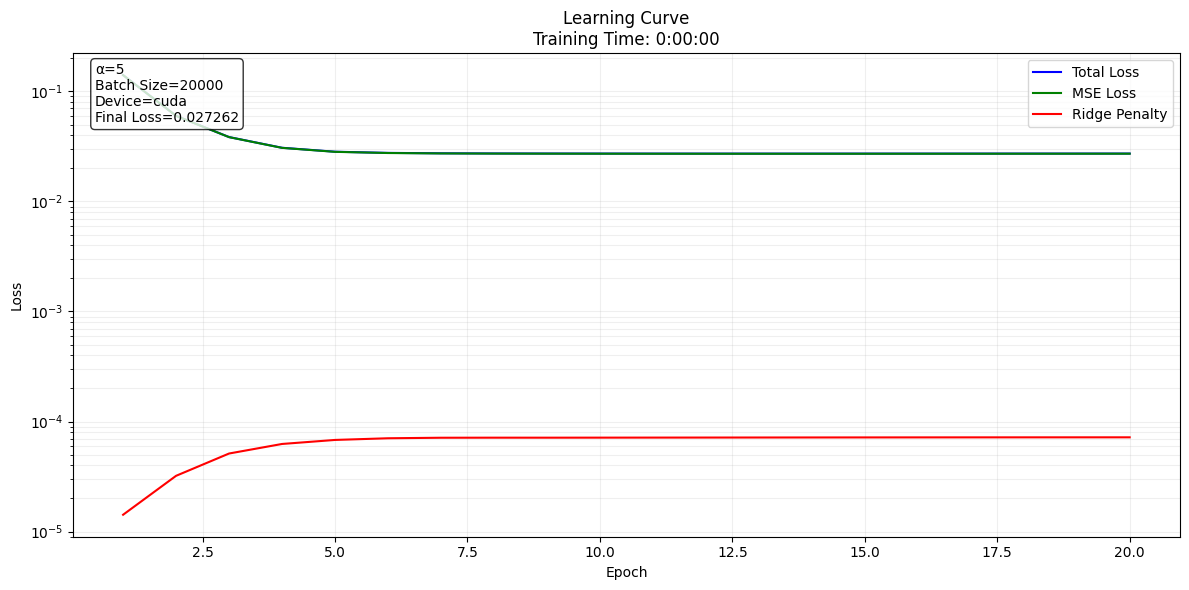

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Need more than one channel to make topography for eeg. Disabling interactivity.


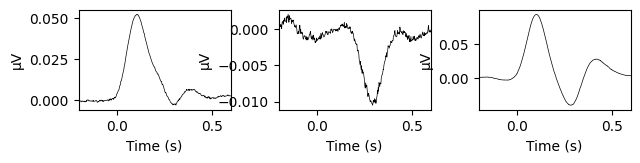

In [28]:

    # Instantiate and train the deconvolution Ridge model
    torch_ridge = RidgeDeconvolution(input_dim=X_design.shape[1], output_dim=1, alpha=5, fit_intercept=False, batch_size=20000, device=device)
    torch_ridge.fit(X_torch, y_torch, epochs=20, lr=0.002)
    
    # Plot learning curve
    torch_ridge.plot_learning_curve()

    # Predictions
    # torch_predictions = torch_ridge.predict(X_torch)
    # print("Predictions shape:", torch_predictions.shape)
    # coeffs =  torch_ridge.linear.weight.detach().cpu().numpy()
    coeffs = torch_ridge.get_coefficients()[0]
    rERP_model.coef_ =  coeffs
    # # Predictions should now have shape (13000, 3)
    # torch_predictions = torch_ridge.predict(X_torch)
    rERP_model.plot_coefs(top_topos=False)


In [ ]:
import torch

def batchwise_ridge_regression(data_loader, D, alpha=1.0, device="cuda"):
    """
    Computes Ridge Regression in a memory-efficient way using streaming batches.
    
    Parameters:
        data_loader: iterable -> Provides (X_batch, y_batch) per iteration
        D: int                -> Number of features in X (columns)
        alpha: float          -> Regularization strength
        device: str           -> "cuda" or "cpu"
    
    Returns:
        beta: torch.Tensor (D, M) -> Regression coefficients
    """
    XtX = torch.zeros((D, D), device=device)
    Xty = None  # Lazy initialization (since y might have multiple targets)

    for X_batch, y_batch in data_loader:  
        X_batch = X_batch.to(device)  
        y_batch = y_batch.to(device)  
        
        # Update XtX and Xty
        XtX += X_batch.T @ X_batch
        
        if Xty is None:  # Initialize Xty based on y's shape
            M = y_batch.shape[1] if y_batch.ndimension() > 1 else 1
            Xty = torch.zeros((D, M), device=device)
        
        Xty += X_batch.T @ y_batch  

    # Regularization term (ridge)
    XtX += alpha * torch.eye(D, device=device)
    
    # Solve (X^T X + alpha I) beta = X^T y using Cholesky
    beta = torch.cholesky_solve(Xty, torch.linalg.cholesky(XtX))

    return beta.cpu()  # Move result back to CPU



In [8]:
import torch.utils.data as data

class LargeDataset(data.Dataset):
    def __init__(self, N, D, M):
        self.N = N
        self.D = D
        self.M = M

    def __len__(self):
        return self.N  # Large number of samples

    def __getitem__(self, index):
        X_sample = torch.randn(self.D)  # Simulate one row of X
        y_sample = torch.randn(self.M)  # Simulate corresponding target
        return X_sample, y_sample

# Parameters
N, D, M = 1300000, 3000, 3  # Large dataset
batch_size = 10000

# Create streaming dataset
dataset = LargeDataset(N, D, M)
data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Solve Ridge regression efficiently
beta = batchwise_ridge_regression(data_loader, D, alpha=1.0, device="cuda")

print("Beta shape:", beta.shape)  # Expected: (D, M)


KeyboardInterrupt: 

In [17]:
y_torch.shape

torch.Size([261699, 1])